# AeroML Reverse Design: Optimization-Based Notebook v3

This version makes the inverse search flow-aware before optimization.

Main changes vs v2:
- feasibility pre-check around the requested `Re` and `Mach`
- local-flow seed pool instead of mostly global seeds
- stronger flow penalty in seed ranking
- local jitter around nearby feasible examples
- uncertainty-aware ranking is kept


In [1]:
from pathlib import Path

COMMON_MODULE_TEXT = 'import hashlib\nimport json\nimport math\nimport os\nimport pickle\nimport warnings\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nfrom sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score\nfrom sklearn.model_selection import GroupShuffleSplit\nfrom sklearn.preprocessing import StandardScaler\nfrom tqdm.auto import tqdm\n\nwarnings.filterwarnings("ignore")\n\nSOURCE_NAME = "XFOIL ncrit=9"\nN_STATIONS = 160\nFINGERPRINT_DECIMALS = 5\nRANDOM_STATE = 42\n\nWORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()\nCACHE_DATA_PATH = WORK_DIR / "aeroml_xfoil_n9_dataset.npz"\nCACHE_META_PATH = WORK_DIR / "aeroml_xfoil_n9_meta.csv"\nSPLIT_MANIFEST_PATH = WORK_DIR / "aeroml_xfoil_split_manifest.csv"\n\n\ndef discover_data_dir():\n    explicit = os.environ.get("AEROML_DATA_DIR")\n    if explicit and Path(explicit).exists():\n        return Path(explicit)\n\n    search_roots = [Path("/kaggle/input"), Path.cwd()]\n    candidates = []\n\n    for root in search_roots:\n        if not root.exists():\n            continue\n\n        for path in root.rglob("*"):\n            if not path.is_dir():\n                continue\n\n            dat_count = len(list(path.glob("*.dat")))\n            if dat_count < 100:\n                continue\n\n            pkl_count = len(list(path.glob("*.pkl")))\n            if dat_count == pkl_count and pkl_count > 0:\n                candidates.append((dat_count, path))\n\n    if not candidates:\n        raise FileNotFoundError(\n            "Could not auto-discover the AeroML dataset. "\n            "Set AEROML_DATA_DIR manually if needed."\n        )\n\n    candidates.sort(key=lambda item: (-item[0], len(str(item[1]))))\n    return candidates[0][1]\n\n\nDATA_DIR = discover_data_dir()\n\n\ndef read_dat_file(path):\n    coords = []\n    with open(path, "r", encoding="utf-8", errors="ignore") as handle:\n        for line in handle:\n            parts = line.strip().split()\n            if len(parts) != 2:\n                continue\n            try:\n                coords.append((float(parts[0]), float(parts[1])))\n            except ValueError:\n                continue\n\n    coords = np.asarray(coords, dtype=np.float64)\n    if len(coords) < 20:\n        return None\n\n    keep = np.ones(len(coords), dtype=bool)\n    keep[1:] = np.any(np.abs(np.diff(coords, axis=0)) > 1e-12, axis=1)\n    coords = coords[keep]\n    return coords if len(coords) >= 20 else None\n\n\ndef normalize_coords(coords):\n    coords = np.asarray(coords, dtype=np.float64).copy()\n    x_min = coords[:, 0].min()\n    x_max = coords[:, 0].max()\n    chord = x_max - x_min\n    if chord <= 1e-8:\n        return None\n\n    coords[:, 0] = (coords[:, 0] - x_min) / chord\n    coords[:, 1] = coords[:, 1] / chord\n    return coords\n\n\ndef split_upper_lower(coords):\n    le_idx = int(np.argmin(coords[:, 0]))\n    upper = coords[: le_idx + 1]\n    lower = coords[le_idx:]\n\n    if len(upper) < 5 or len(lower) < 5:\n        return None, None\n\n    if upper[0, 0] < upper[-1, 0]:\n        upper = upper[::-1]\n    if lower[0, 0] > lower[-1, 0]:\n        lower = lower[::-1]\n\n    return upper, lower\n\n\ndef prepare_surface_for_interp(surface):\n    surface = np.asarray(surface, dtype=np.float64)\n    order = np.argsort(surface[:, 0])\n    surface = surface[order]\n\n    rounded_x = np.round(surface[:, 0], 10)\n    _, unique_idx = np.unique(rounded_x, return_index=True)\n    surface = surface[np.sort(unique_idx)]\n    return surface if len(surface) >= 5 else None\n\n\ndef cosine_spacing(n_stations):\n    beta = np.linspace(0.0, np.pi, n_stations)\n    return 0.5 * (1.0 - np.cos(beta))\n\n\ndef estimate_le_radius(x_grid, thickness):\n    nose_x = x_grid[1:6]\n    nose_t = thickness[1:6]\n    radius = 0.5 * (nose_t ** 2) / np.clip(nose_x, 1e-6, None)\n    return float(np.median(radius))\n\n\ndef geometry_representation(dat_path, n_stations=N_STATIONS):\n    coords = read_dat_file(dat_path)\n    if coords is None:\n        return None\n\n    coords = normalize_coords(coords)\n    if coords is None:\n        return None\n\n    upper, lower = split_upper_lower(coords)\n    if upper is None or lower is None:\n        return None\n\n    upper = prepare_surface_for_interp(upper)\n    lower = prepare_surface_for_interp(lower)\n    if upper is None or lower is None:\n        return None\n\n    x_grid = cosine_spacing(n_stations)\n    y_upper = np.interp(x_grid, upper[:, 0], upper[:, 1])\n    y_lower = np.interp(x_grid, lower[:, 0], lower[:, 1])\n\n    thickness = y_upper - y_lower\n    camber = 0.5 * (y_upper + y_lower)\n    dyu_dx = np.gradient(y_upper, x_grid)\n    dyl_dx = np.gradient(y_lower, x_grid)\n\n    curv_upper = np.gradient(dyu_dx, x_grid) / np.maximum((1.0 + dyu_dx**2) ** 1.5, 1e-6)\n    curv_lower = np.gradient(dyl_dx, x_grid) / np.maximum((1.0 + dyl_dx**2) ** 1.5, 1e-6)\n\n    max_t_idx = int(np.argmax(thickness))\n    max_c_idx = int(np.argmax(np.abs(camber)))\n\n    scalar_features = np.array(\n        [\n            thickness[max_t_idx],\n            x_grid[max_t_idx],\n            camber[max_c_idx],\n            x_grid[max_c_idx],\n            np.max(camber),\n            np.min(camber),\n            estimate_le_radius(x_grid, thickness),\n            thickness[-1],\n            math.degrees(math.atan(dyu_dx[-1]) - math.atan(dyl_dx[-1])),\n            np.trapz(thickness, x_grid),\n            np.sum(np.sqrt(np.diff(x_grid) ** 2 + np.diff(y_upper) ** 2)),\n            np.sum(np.sqrt(np.diff(x_grid) ** 2 + np.diff(y_lower) ** 2)),\n            np.mean(np.abs(curv_upper)),\n            np.mean(np.abs(curv_lower)),\n            np.max(np.abs(curv_upper)),\n            np.max(np.abs(curv_lower)),\n        ],\n        dtype=np.float32,\n    )\n\n    profile_features = np.concatenate([thickness, camber, dyu_dx, dyl_dx], axis=0).astype(np.float32)\n    fingerprint_payload = np.round(np.concatenate([y_upper, y_lower]), FINGERPRINT_DECIMALS).astype(np.float32)\n    fingerprint = hashlib.sha1(fingerprint_payload.tobytes()).hexdigest()\n\n    return {\n        "profile": profile_features,\n        "scalar": scalar_features,\n        "fingerprint": fingerprint,\n    }\n\n\ndef build_flow_features(re_value, mach_value):\n    re_value = float(re_value)\n    mach_value = float(mach_value)\n    return np.array(\n        [\n            np.log10(re_value),\n            mach_value,\n            mach_value**2,\n            1.0 / np.sqrt(re_value),\n            1.0 / np.sqrt(max(1.0 - mach_value**2, 1e-6)),\n        ],\n        dtype=np.float32,\n    )\n\n\ndef build_or_load_cached_dataset():\n    if CACHE_DATA_PATH.exists() and CACHE_META_PATH.exists():\n        cached = np.load(CACHE_DATA_PATH, allow_pickle=True)\n        meta = pd.read_csv(CACHE_META_PATH)\n        return (\n            cached["X_profile"].astype(np.float32),\n            cached["X_scalar"].astype(np.float32),\n            cached["X_flow"].astype(np.float32),\n            cached["y_targets"].astype(np.float32),\n            meta,\n        )\n\n    dat_paths = sorted(DATA_DIR.glob("*.dat"))\n    geom_by_fp = {}\n    rows = []\n\n    for dat_path in tqdm(dat_paths, desc="Parsing airfoils"):\n        name = dat_path.stem\n        pkl_path = DATA_DIR / f"{name}.pkl"\n        if not pkl_path.exists():\n            continue\n\n        geom = geometry_representation(dat_path)\n        if geom is None:\n            continue\n\n        geom_by_fp[geom["fingerprint"]] = geom\n\n        try:\n            df = pd.read_pickle(pkl_path)\n        except Exception as exc:\n            print(f"Skipping {pkl_path.name}: {exc}")\n            continue\n\n        required_cols = {"datasource", "Re", "Mach", "LDMax", "ClMax", "CdMin"}\n        if not required_cols.issubset(df.columns):\n            continue\n\n        df = df.loc[df["datasource"].astype(str) == SOURCE_NAME, ["Re", "Mach", "LDMax", "ClMax", "CdMin"]].copy()\n        if df.empty:\n            continue\n\n        for col in ["Re", "Mach", "LDMax", "ClMax", "CdMin"]:\n            df[col] = pd.to_numeric(df[col], errors="coerce")\n\n        df = df.replace([-99, -99.0], np.nan).dropna()\n        df = df[\n            (df["ClMax"] > 0.0)\n            & (df["ClMax"] < 5.0)\n            & (df["CdMin"] > 0.0)\n            & (df["CdMin"] < 1.0)\n            & (df["LDMax"] > 0.0)\n            & (df["LDMax"] < 500.0)\n        ].copy()\n        if df.empty:\n            continue\n\n        df = df.groupby(["Re", "Mach"], as_index=False)[["LDMax", "ClMax", "CdMin"]].median()\n        for row in df.itertuples(index=False):\n            rows.append(\n                {\n                    "name": name,\n                    "fingerprint": geom["fingerprint"],\n                    "Re": float(row.Re),\n                    "Mach": float(row.Mach),\n                    "LDMax": float(row.LDMax),\n                    "ClMax": float(row.ClMax),\n                    "CdMin": float(row.CdMin),\n                }\n            )\n\n    if not rows:\n        raise RuntimeError("No XFOIL rows survived the filtering step.")\n\n    raw_meta = pd.DataFrame(rows)\n    meta = (\n        raw_meta.groupby(["fingerprint", "Re", "Mach"], as_index=False)\n        .agg(\n            LDMax=("LDMax", "median"),\n            ClMax=("ClMax", "median"),\n            CdMin=("CdMin", "median"),\n            duplicate_rows=("name", "size"),\n            duplicate_names=("name", "nunique"),\n            example_name=("name", "first"),\n        )\n    )\n\n    X_profile = np.stack([geom_by_fp[fp]["profile"] for fp in meta["fingerprint"]], axis=0).astype(np.float32)\n    X_scalar = np.stack([geom_by_fp[fp]["scalar"] for fp in meta["fingerprint"]], axis=0).astype(np.float32)\n    X_flow = np.stack(\n        [build_flow_features(re_val, mach_val) for re_val, mach_val in zip(meta["Re"], meta["Mach"])],\n        axis=0,\n    ).astype(np.float32)\n    y_targets = meta[["LDMax", "ClMax", "CdMin"]].to_numpy(dtype=np.float32)\n\n    np.savez_compressed(\n        CACHE_DATA_PATH,\n        X_profile=X_profile,\n        X_scalar=X_scalar,\n        X_flow=X_flow,\n        y_targets=y_targets,\n    )\n    meta.to_csv(CACHE_META_PATH, index=False)\n    return X_profile, X_scalar, X_flow, y_targets, meta\n\n\ndef build_or_load_split_manifest(meta, random_state=RANDOM_STATE):\n    if SPLIT_MANIFEST_PATH.exists():\n        manifest = pd.read_csv(SPLIT_MANIFEST_PATH)\n        if set(manifest["split"]) == {"train", "val", "test"}:\n            return manifest\n\n    sample_index = np.arange(len(meta))\n    groups = meta["fingerprint"].to_numpy()\n\n    outer_split = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=random_state)\n    train_val_idx, test_idx = next(outer_split.split(sample_index, groups=groups))\n\n    inner_split = GroupShuffleSplit(n_splits=1, test_size=0.111111, random_state=random_state)\n    train_rel_idx, val_rel_idx = next(inner_split.split(train_val_idx, groups=groups[train_val_idx]))\n    train_idx = train_val_idx[train_rel_idx]\n    val_idx = train_val_idx[val_rel_idx]\n\n    split_labels = np.full(len(meta), "unassigned", dtype=object)\n    split_labels[train_idx] = "train"\n    split_labels[val_idx] = "val"\n    split_labels[test_idx] = "test"\n\n    manifest = (\n        pd.DataFrame({"fingerprint": meta["fingerprint"], "split": split_labels})\n        .drop_duplicates()\n        .sort_values(["split", "fingerprint"])\n        .reset_index(drop=True)\n    )\n    manifest.to_csv(SPLIT_MANIFEST_PATH, index=False)\n    return manifest\n\n\ndef materialize_indices(meta, manifest):\n    split_map = dict(zip(manifest["fingerprint"], manifest["split"]))\n    split_series = meta["fingerprint"].map(split_map)\n    train_idx = np.flatnonzero(split_series.to_numpy() == "train")\n    val_idx = np.flatnonzero(split_series.to_numpy() == "val")\n    test_idx = np.flatnonzero(split_series.to_numpy() == "test")\n    return train_idx, val_idx, test_idx\n\n\ndef fit_transform_standard(train_array, val_array, test_array):\n    scaler = StandardScaler()\n    train_scaled = scaler.fit_transform(train_array).astype(np.float32)\n    val_scaled = scaler.transform(val_array).astype(np.float32)\n    test_scaled = scaler.transform(test_array).astype(np.float32)\n    return scaler, train_scaled, val_scaled, test_scaled\n\n\ndef regression_report(y_true, y_pred):\n    mae = float(mean_absolute_error(y_true, y_pred))\n    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))\n    r2 = float(r2_score(y_true, y_pred)) if len(np.unique(y_true)) > 1 else float("nan")\n    return {"MAE": mae, "RMSE": rmse, "R2": r2}\n\n\ndef write_json(path, payload):\n    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")\n\n\ndef add_tf_helpers(namespace):\n    import tensorflow as tf\n    from tensorflow import keras\n    from tensorflow.keras import layers\n\n    namespace["tf"] = tf\n    namespace["keras"] = keras\n    namespace["layers"] = layers\n\n    def set_all_seeds(seed):\n        np.random.seed(seed)\n        tf.random.set_seed(seed)\n        keras.utils.set_random_seed(seed)\n\n    def dense_block(x, units, dropout):\n        x = layers.Dense(units, kernel_initializer="he_normal")(x)\n        x = layers.LayerNormalization()(x)\n        x = layers.Activation("swish")(x)\n        if dropout > 0:\n            x = layers.Dropout(dropout)(x)\n        return x\n\n    def build_forward_model(profile_dim, scalar_dim, flow_dim):\n        profile_in = layers.Input(shape=(profile_dim,), name="profile")\n        scalar_in = layers.Input(shape=(scalar_dim,), name="scalar")\n        flow_in = layers.Input(shape=(flow_dim,), name="flow")\n\n        p = layers.GaussianNoise(0.01)(profile_in)\n        p = dense_block(p, 512, 0.10)\n        p = dense_block(p, 256, 0.10)\n        p = dense_block(p, 128, 0.05)\n\n        s = dense_block(scalar_in, 64, 0.05)\n        s = dense_block(s, 32, 0.00)\n\n        f = dense_block(flow_in, 64, 0.05)\n        f = dense_block(f, 32, 0.00)\n\n        x = layers.Concatenate()([p, s, f])\n        x = dense_block(x, 256, 0.10)\n        x = dense_block(x, 128, 0.05)\n        shared = dense_block(x, 64, 0.00)\n\n        ld_head = dense_block(shared, 32, 0.00)\n        cl_head = dense_block(shared, 32, 0.00)\n        cd_head = dense_block(shared, 32, 0.00)\n\n        outputs = {\n            "ldmax": layers.Dense(1, name="ldmax")(ld_head),\n            "clmax": layers.Dense(1, name="clmax")(cl_head),\n            "cdmin_log": layers.Dense(1, name="cdmin_log")(cd_head),\n        }\n\n        return keras.Model(\n            inputs=[profile_in, scalar_in, flow_in],\n            outputs=outputs,\n            name="AeroML_XFOIL_Forward_MLP",\n        )\n\n    namespace["set_all_seeds"] = set_all_seeds\n    namespace["build_forward_model"] = build_forward_model\n\n\ndef decode_predictions(pred_scaled, ld_scaler, cl_scaler, cd_scaler):\n    ld_pred = ld_scaler.inverse_transform(pred_scaled["ldmax"]).ravel()\n    cl_pred = cl_scaler.inverse_transform(pred_scaled["clmax"]).ravel()\n    cd_log = cd_scaler.inverse_transform(pred_scaled["cdmin_log"]).ravel()\n    cd_pred = np.exp(cd_log)\n    return np.column_stack([ld_pred, cl_pred, cd_pred]), cd_log\n\n\ndef collect_metrics(y_true, y_pred):\n    metrics = {\n        "LDMax": regression_report(y_true[:, 0], y_pred[:, 0]),\n        "ClMax": regression_report(y_true[:, 1], y_pred[:, 1]),\n        "CdMin": regression_report(y_true[:, 2], y_pred[:, 2]),\n    }\n    cd_rel_err = np.abs((y_pred[:, 2] - y_true[:, 2]) / np.clip(y_true[:, 2], 1e-8, None))\n    metrics["CdMin"]["MedianAE"] = float(np.median(np.abs(y_pred[:, 2] - y_true[:, 2])))\n    metrics["CdMin"]["Within10Pct"] = float((cd_rel_err <= 0.10).mean())\n    metrics["CdMin"]["Within25Pct"] = float((cd_rel_err <= 0.25).mean())\n    metrics["CdMin"]["Within50Pct"] = float((cd_rel_err <= 0.50).mean())\n    return metrics\n'
Path("aeroml_notebook_common.py").write_text(COMMON_MODULE_TEXT, encoding="utf-8")
print("Bootstrapped aeroml_notebook_common.py")


Bootstrapped aeroml_notebook_common.py


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.decomposition import PCA

import aeroml_notebook_common as common

common.add_tf_helpers(globals())

TARGET = {"LDMax": 180.0, "ClMax": 1.85, "CdMin": 0.020}
FLOW = {"Re": 2_000_000.0, "Mach": 0.10}

N_COMPONENTS = 12
N_RESTARTS = 8
TOP_K = 5
OPT_MAXITER = 35

LOCAL_RE_LOG_TOL = 0.18
LOCAL_MACH_TOL = 0.10
LOCAL_POOL_MIN = 80
INIT_POOL_SIZE = 24

ELITE_SEEDS = 4
JITTER_SEEDS_PER_ELITE = 2
RANDOM_LOCAL_SEEDS = 4

TARGET_WEIGHTS = {"LDMax": 1.0, "ClMax": 1.0, "CdMin": 1.15}
FLOW_SEED_WEIGHTS = {"re_log": 2.50, "mach": 5.00}

DISAGREEMENT_PENALTY = 0.25
GEOMETRY_PENALTY = 10.0
CD_REL_STD_PENALTY = 0.35
MAX_CD_REL_STD = 0.60
MAX_LDMAX_STD_NORM = 0.18
MAX_CLMAX_STD_NORM = 0.18

OUT_DIR = common.WORK_DIR / "aeroml_reverse_design_v3"
OUT_DIR.mkdir(exist_ok=True)

SUMMARY_PATH = OUT_DIR / "reverse_design_v3_summary.json"
CANDIDATE_TABLE_PATH = OUT_DIR / "reverse_design_v3_candidates.csv"
ALL_RESULTS_PATH = OUT_DIR / "reverse_design_v3_all_results.csv"
FEASIBILITY_PATH = OUT_DIR / "reverse_design_v3_feasibility.json"

print("Target coefficients:", TARGET)
print("Flow condition:", FLOW)
print("Using DATA_DIR:", common.DATA_DIR)
print("TensorFlow:", tf.__version__)
print("GPU count:", len(tf.config.list_physical_devices("GPU")))


2026-04-05 14:29:28.437486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775399368.837547      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775399368.950706      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775399369.900284      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775399369.900334      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775399369.900337      24 computation_placer.cc:177] computation placer alr

Target coefficients: {'LDMax': 180.0, 'ClMax': 1.85, 'CdMin': 0.02}
Flow condition: {'Re': 2000000.0, 'Mach': 0.1}
Using DATA_DIR: /kaggle/input/datasets/sanidhyavijay24/bigfoil-data
TensorFlow: 2.19.0
GPU count: 1


In [3]:
REQUIRED_FILES = [
    "aeroml_xfoil_n9_dataset.npz",
    "aeroml_xfoil_n9_meta.csv",
    "aeroml_xfoil_split_manifest.csv",
    "aeroml_xfoil_forward_v1_metrics.json",
]


def find_file(filename):
    search_roots = [common.WORK_DIR, Path("/kaggle/input"), Path.cwd()]
    for root in search_roots:
        if not root.exists():
            continue
        matches = list(root.rglob(filename))
        if matches:
            matches.sort(key=lambda p: len(str(p)))
            return matches[0]
    raise FileNotFoundError(f"Could not find required file: {filename}")


for required in REQUIRED_FILES:
    print(required, "->", find_file(required))

v3_metrics_path = find_file("aeroml_xfoil_forward_v3_ensemble_metrics.json")
v3_metrics = json.loads(v3_metrics_path.read_text(encoding="utf-8"))
chosen_variant = v3_metrics["chosen_variant"]
print("Chosen forward v3 variant:", chosen_variant)

model_paths = []
for seed in [42, 52, 62]:
    filename = f"aeroml_xfoil_forward_v3_{chosen_variant}_seed{seed}.keras"
    model_paths.append(find_file(filename))

X_profile, X_scalar, X_flow, y_targets, meta = common.build_or_load_cached_dataset()
split_manifest = pd.read_csv(find_file("aeroml_xfoil_split_manifest.csv"))
train_idx, val_idx, test_idx = common.materialize_indices(meta, split_manifest)

profile_scaler, Xp_train, Xp_val, Xp_test = common.fit_transform_standard(
    X_profile[train_idx], X_profile[val_idx], X_profile[test_idx]
)
scalar_scaler, Xs_train, Xs_val, Xs_test = common.fit_transform_standard(
    X_scalar[train_idx], X_scalar[val_idx], X_scalar[test_idx]
)
flow_scaler, Xf_train, Xf_val, Xf_test = common.fit_transform_standard(
    X_flow[train_idx], X_flow[val_idx], X_flow[test_idx]
)

y_train_raw = y_targets[train_idx]
train_meta = meta.iloc[train_idx].reset_index(drop=True)
models = [keras.models.load_model(path, compile=False) for path in model_paths]
print("Loaded models:", len(models))


aeroml_xfoil_n9_dataset.npz -> /kaggle/input/notebooks/sanidhyavijay24/aeroml-v3/aeroml_xfoil_n9_dataset.npz
aeroml_xfoil_n9_meta.csv -> /kaggle/input/notebooks/sanidhyavijay24/aeroml-v3/aeroml_xfoil_n9_meta.csv
aeroml_xfoil_split_manifest.csv -> /kaggle/input/notebooks/sanidhyavijay24/aeroml-v3/aeroml_xfoil_split_manifest.csv
aeroml_xfoil_forward_v1_metrics.json -> /kaggle/input/notebooks/sanidhyavijay24/aeroml-v3/aeroml_xfoil_forward_v1_metrics.json
Chosen forward v3 variant: cd_loss_only


Parsing airfoils:   0%|          | 0/6351 [00:00<?, ?it/s]

I0000 00:00:1775399774.430797      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Loaded models: 3


In [4]:
n_stations = common.N_STATIONS
x_grid = common.cosine_spacing(n_stations)
rng = np.random.default_rng(common.RANDOM_STATE)

thickness_train = X_profile[train_idx, :n_stations]
camber_train = X_profile[train_idx, n_stations : 2 * n_stations]
shape_train = np.concatenate([thickness_train, camber_train], axis=1).astype(np.float32)

pca = PCA(n_components=N_COMPONENTS, random_state=common.RANDOM_STATE)
z_train = pca.fit_transform(shape_train)
latent_low = np.quantile(z_train, 0.01, axis=0)
latent_high = np.quantile(z_train, 0.99, axis=0)
latent_span = np.maximum(latent_high - latent_low, 1e-6)
latent_bounds = list(zip(latent_low, latent_high))

max_thickness_train = thickness_train.max(axis=1)
max_camber_train = np.abs(camber_train).max(axis=1)
te_thickness_train = thickness_train[:, -1]
geom_limits = {
    "max_thickness_min": float(np.quantile(max_thickness_train, 0.001)),
    "max_thickness_max": float(np.quantile(max_thickness_train, 0.999)),
    "max_camber_max": float(np.quantile(max_camber_train, 0.999)),
    "te_thickness_min": float(np.quantile(te_thickness_train, 0.001)),
    "te_thickness_max": float(np.quantile(te_thickness_train, 0.999)),
}

ld_scale = float(np.std(y_train_raw[:, 0]))
cl_scale = float(np.std(y_train_raw[:, 1]))
cd_log_scale = float(np.std(np.log(y_train_raw[:, 2])))

flow_vector = common.build_flow_features(FLOW["Re"], FLOW["Mach"]).reshape(1, -1)
flow_scaled = flow_scaler.transform(flow_vector).astype(np.float32)
ld_scaler = common.StandardScaler().fit(y_train_raw[:, [0]])
cl_scaler = common.StandardScaler().fit(y_train_raw[:, [1]])
cd_scaler = common.StandardScaler().fit(np.log(y_train_raw[:, [2]]))


def shape_from_latent(z):
    clipped = np.clip(np.asarray(z, dtype=np.float64), latent_low, latent_high)
    shape = pca.inverse_transform(clipped.reshape(1, -1))[0]
    thickness = shape[:n_stations]
    camber = shape[n_stations:]
    y_upper = camber + 0.5 * thickness
    y_lower = camber - 0.5 * thickness
    dyu_dx = np.gradient(y_upper, x_grid)
    dyl_dx = np.gradient(y_lower, x_grid)
    return clipped, thickness, camber, y_upper, y_lower, dyu_dx, dyl_dx


def scalar_from_surfaces(thickness, camber, y_upper, y_lower, dyu_dx, dyl_dx):
    curv_upper = np.gradient(dyu_dx, x_grid) / np.maximum((1.0 + dyu_dx**2) ** 1.5, 1e-6)
    curv_lower = np.gradient(dyl_dx, x_grid) / np.maximum((1.0 + dyl_dx**2) ** 1.5, 1e-6)
    max_t_idx = int(np.argmax(thickness))
    max_c_idx = int(np.argmax(np.abs(camber)))
    return np.array(
        [
            thickness[max_t_idx], x_grid[max_t_idx], camber[max_c_idx], x_grid[max_c_idx],
            np.max(camber), np.min(camber), common.estimate_le_radius(x_grid, thickness),
            thickness[-1], np.degrees(np.arctan(dyu_dx[-1]) - np.arctan(dyl_dx[-1])),
            np.trapz(thickness, x_grid),
            np.sum(np.sqrt(np.diff(x_grid) ** 2 + np.diff(y_upper) ** 2)),
            np.sum(np.sqrt(np.diff(x_grid) ** 2 + np.diff(y_lower) ** 2)),
            np.mean(np.abs(curv_upper)), np.mean(np.abs(curv_lower)),
            np.max(np.abs(curv_upper)), np.max(np.abs(curv_lower)),
        ],
        dtype=np.float32,
    )


def build_model_inputs(z):
    z_clipped, thickness, camber, y_upper, y_lower, dyu_dx, dyl_dx = shape_from_latent(z)
    profile = np.concatenate([thickness, camber, dyu_dx, dyl_dx], axis=0).astype(np.float32).reshape(1, -1)
    scalar = scalar_from_surfaces(thickness, camber, y_upper, y_lower, dyu_dx, dyl_dx).reshape(1, -1)
    return {
        "latent": z_clipped,
        "profile_scaled": profile_scaler.transform(profile).astype(np.float32),
        "scalar_scaled": scalar_scaler.transform(scalar).astype(np.float32),
        "flow_scaled": flow_scaled,
        "thickness": thickness,
        "camber": camber,
        "y_upper": y_upper,
        "y_lower": y_lower,
    }


def ensemble_predict(z):
    inputs = build_model_inputs(z)
    preds = []
    for model in models:
        pred_scaled = model(
            {"profile": inputs["profile_scaled"], "scalar": inputs["scalar_scaled"], "flow": inputs["flow_scaled"]},
            training=False,
        )
        pred_scaled = {key: value.numpy() for key, value in pred_scaled.items()}
        pred, _ = common.decode_predictions(pred_scaled, ld_scaler, cl_scaler, cd_scaler)
        preds.append(pred[0])
    preds = np.asarray(preds, dtype=np.float64)
    return preds, preds.mean(axis=0), preds.std(axis=0), inputs


In [5]:
def geometry_penalty(inputs):
    thickness = inputs["thickness"]
    camber = inputs["camber"]
    penalty = 0.0
    if thickness.min() < -1e-4:
        penalty += GEOMETRY_PENALTY * abs(float(thickness.min()))
    if thickness.max() < geom_limits["max_thickness_min"]:
        penalty += GEOMETRY_PENALTY * (geom_limits["max_thickness_min"] - float(thickness.max()))
    if thickness.max() > geom_limits["max_thickness_max"]:
        penalty += GEOMETRY_PENALTY * (float(thickness.max()) - geom_limits["max_thickness_max"])
    if np.abs(camber).max() > geom_limits["max_camber_max"]:
        penalty += GEOMETRY_PENALTY * (float(np.abs(camber).max()) - geom_limits["max_camber_max"])
    if thickness[-1] < geom_limits["te_thickness_min"]:
        penalty += GEOMETRY_PENALTY * (geom_limits["te_thickness_min"] - float(thickness[-1]))
    if thickness[-1] > geom_limits["te_thickness_max"]:
        penalty += GEOMETRY_PENALTY * (float(thickness[-1]) - geom_limits["te_thickness_max"])
    return float(penalty)


def flow_distance_frame(frame):
    return pd.DataFrame(
        {
            "re_log_abs": np.abs(np.log10(frame["Re"]) - np.log10(FLOW["Re"])),
            "mach_abs": np.abs(frame["Mach"] - FLOW["Mach"]),
        },
        index=frame.index,
    )


def local_flow_pool():
    flow_dist = flow_distance_frame(train_meta)
    local_mask = (
        (flow_dist["re_log_abs"] <= LOCAL_RE_LOG_TOL)
        & (flow_dist["mach_abs"] <= LOCAL_MACH_TOL)
    )
    local = train_meta.loc[local_mask].copy()
    local_dist = flow_dist.loc[local_mask].copy()
    if len(local) < LOCAL_POOL_MIN:
        ranked_idx = (
            flow_dist.assign(
                flow_rank=FLOW_SEED_WEIGHTS["re_log"] * flow_dist["re_log_abs"]
                + FLOW_SEED_WEIGHTS["mach"] * flow_dist["mach_abs"]
            )
            .sort_values("flow_rank")
            .head(LOCAL_POOL_MIN)
            .index
        )
        local = train_meta.loc[ranked_idx].copy()
        local_dist = flow_dist.loc[ranked_idx].copy()
    local["re_log_abs"] = local_dist["re_log_abs"]
    local["mach_abs"] = local_dist["mach_abs"]
    local["flow_rank"] = (
        FLOW_SEED_WEIGHTS["re_log"] * local["re_log_abs"]
        + FLOW_SEED_WEIGHTS["mach"] * local["mach_abs"]
    )
    return local.sort_values(["flow_rank", "re_log_abs", "mach_abs"]).copy()


def feasibility_summary(local_pool):
    q05 = local_pool[["LDMax", "ClMax", "CdMin"]].quantile(0.05)
    q95 = local_pool[["LDMax", "ClMax", "CdMin"]].quantile(0.95)
    min_v = local_pool[["LDMax", "ClMax", "CdMin"]].min()
    max_v = local_pool[["LDMax", "ClMax", "CdMin"]].max()
    return {
        "count": int(len(local_pool)),
        "local_re_range": [float(local_pool["Re"].min()), float(local_pool["Re"].max())],
        "local_mach_values": sorted(float(v) for v in local_pool["Mach"].unique()),
        "target_within_local_5_95": {
            "LDMax": bool(q05["LDMax"] <= TARGET["LDMax"] <= q95["LDMax"]),
            "ClMax": bool(q05["ClMax"] <= TARGET["ClMax"] <= q95["ClMax"]),
            "CdMin": bool(q05["CdMin"] <= TARGET["CdMin"] <= q95["CdMin"]),
        },
        "target_within_local_min_max": {
            "LDMax": bool(min_v["LDMax"] <= TARGET["LDMax"] <= max_v["LDMax"]),
            "ClMax": bool(min_v["ClMax"] <= TARGET["ClMax"] <= max_v["ClMax"]),
            "CdMin": bool(min_v["CdMin"] <= TARGET["CdMin"] <= max_v["CdMin"]),
        },
        "ranges": {
            "LDMax": [float(min_v["LDMax"]), float(max_v["LDMax"])],
            "ClMax": [float(min_v["ClMax"]), float(max_v["ClMax"])],
            "CdMin": [float(min_v["CdMin"]), float(max_v["CdMin"])],
        },
    }


def candidate_pool(local_pool):
    score = (
        TARGET_WEIGHTS["LDMax"] * np.abs((local_pool["LDMax"] - TARGET["LDMax"]) / max(ld_scale, 1e-6))
        + TARGET_WEIGHTS["ClMax"] * np.abs((local_pool["ClMax"] - TARGET["ClMax"]) / max(cl_scale, 1e-6))
        + TARGET_WEIGHTS["CdMin"] * np.abs((np.log(local_pool["CdMin"]) - np.log(TARGET["CdMin"])) / max(cd_log_scale, 1e-6))
        + FLOW_SEED_WEIGHTS["re_log"] * local_pool["re_log_abs"]
        + FLOW_SEED_WEIGHTS["mach"] * local_pool["mach_abs"]
    )
    return local_pool.assign(init_score=score).sort_values(["init_score", "flow_rank"]).head(INIT_POOL_SIZE).copy()


def dedupe_latent_seeds(seed_items, min_distance=0.25):
    kept = []
    for item in seed_items:
        z = np.asarray(item["latent"], dtype=np.float64)
        if not kept:
            kept.append({**item, "latent": z})
            continue
        dists = [np.linalg.norm(z - prev["latent"]) for prev in kept]
        if min(dists) >= min_distance:
            kept.append({**item, "latent": z})
    return kept


def build_init_seeds(init_pool, local_pool):
    seed_items = []
    elite_pool = init_pool.head(ELITE_SEEDS)
    elite_indices = elite_pool.index.to_numpy()
    elite_z = z_train[elite_indices]
    for rank, (row, z0) in enumerate(zip(elite_pool.itertuples(index=False), elite_z), start=1):
        seed_items.append({"latent": z0, "source": f"elite_{rank}", "example_name": row.example_name, "init_score": float(row.init_score)})
    jitter_scale = 0.06 * latent_span
    for rank, (row, z0) in enumerate(zip(elite_pool.itertuples(index=False), elite_z), start=1):
        for jitter_id in range(JITTER_SEEDS_PER_ELITE):
            z_jitter = np.clip(z0 + rng.normal(scale=jitter_scale, size=z0.shape), latent_low, latent_high)
            seed_items.append({"latent": z_jitter, "source": f"jitter_{rank}_{jitter_id+1}", "example_name": row.example_name, "init_score": float(row.init_score)})
    if len(local_pool) > 0 and RANDOM_LOCAL_SEEDS > 0:
        local_indices = local_pool.index.to_numpy()
        prob = 1.0 / np.maximum(local_pool["flow_rank"].to_numpy(dtype=np.float64) + 1e-6, 1e-6)
        prob = prob / prob.sum()
        sample_size = min(RANDOM_LOCAL_SEEDS, len(local_indices))
        picked = rng.choice(local_indices, size=sample_size, replace=False, p=prob)
        for pick_id, idx in enumerate(picked, start=1):
            row = train_meta.loc[idx]
            seed_items.append({"latent": z_train[idx], "source": f"local_random_{pick_id}", "example_name": str(row['example_name']), "init_score": float('nan')})
    seed_items = dedupe_latent_seeds(seed_items)
    return seed_items[:N_RESTARTS]


def objective(z):
    preds, mean_pred, std_pred, inputs = ensemble_predict(z)
    ld_term = TARGET_WEIGHTS["LDMax"] * ((mean_pred[0] - TARGET["LDMax"]) / max(ld_scale, 1e-6)) ** 2
    cl_term = TARGET_WEIGHTS["ClMax"] * ((mean_pred[1] - TARGET["ClMax"]) / max(cl_scale, 1e-6)) ** 2
    cd_term = TARGET_WEIGHTS["CdMin"] * ((np.log(max(mean_pred[2], 1e-8)) - np.log(TARGET["CdMin"])) / max(cd_log_scale, 1e-6)) ** 2
    disagreement = DISAGREEMENT_PENALTY * (
        (std_pred[0] / max(ld_scale, 1e-6))
        + (std_pred[1] / max(cl_scale, 1e-6))
        + (std_pred[2] / max(TARGET["CdMin"], 1e-6))
    )
    cd_rel_std = std_pred[2] / max(mean_pred[2], 1e-6)
    uncertainty_penalty = CD_REL_STD_PENALTY * max(cd_rel_std - 0.25, 0.0)
    return float(ld_term + cl_term + cd_term + disagreement + uncertainty_penalty + geometry_penalty(inputs))


def summarize_candidate(seed_meta, candidate):
    pred_mean = candidate["pred_mean"]
    pred_std = candidate["pred_std"]
    ld_std_norm = pred_std[0] / max(ld_scale, 1e-6)
    cl_std_norm = pred_std[1] / max(cl_scale, 1e-6)
    cd_rel_std = pred_std[2] / max(pred_mean[2], 1e-6)
    target_gap = (
        abs(pred_mean[0] - TARGET["LDMax"]) / max(TARGET["LDMax"], 1e-6)
        + abs(pred_mean[1] - TARGET["ClMax"]) / max(TARGET["ClMax"], 1e-6)
        + abs(pred_mean[2] - TARGET["CdMin"]) / max(TARGET["CdMin"], 1e-6)
    )
    return {
        "restart": seed_meta["restart"],
        "source": seed_meta["source"],
        "seed_example_name": seed_meta["example_name"],
        "init_score": seed_meta["init_score"],
        "success": candidate["success"],
        "message": candidate["message"],
        "objective": candidate["objective"],
        "LDMax_pred": pred_mean[0],
        "ClMax_pred": pred_mean[1],
        "CdMin_pred": pred_mean[2],
        "LDMax_std": pred_std[0],
        "ClMax_std": pred_std[1],
        "CdMin_std": pred_std[2],
        "LDMax_std_norm": ld_std_norm,
        "ClMax_std_norm": cl_std_norm,
        "CdMin_rel_std": cd_rel_std,
        "target_gap": target_gap,
        "max_thickness": float(candidate["inputs"]["thickness"].max()),
        "max_camber_abs": float(np.abs(candidate["inputs"]["camber"]).max()),
        "te_thickness": float(candidate["inputs"]["thickness"][-1]),
        "passes_uncertainty": bool((cd_rel_std <= MAX_CD_REL_STD) and (ld_std_norm <= MAX_LDMAX_STD_NORM) and (cl_std_norm <= MAX_CLMAX_STD_NORM)),
    }


local_pool = local_flow_pool()
feasibility = feasibility_summary(local_pool)
FEASIBILITY_PATH.write_text(json.dumps(feasibility, indent=2), encoding="utf-8")
print("Local flow feasibility summary")
print("=" * 72)
print(json.dumps(feasibility, indent=2))

init_pool = candidate_pool(local_pool)
print("\nFlow-aware initialization pool")
print(init_pool[["example_name", "Re", "Mach", "LDMax", "ClMax", "CdMin", "flow_rank", "init_score"]].head(10).to_string(index=False))

seed_items = build_init_seeds(init_pool, local_pool)
print("\nChosen restart seeds")
print(pd.DataFrame(seed_items)[["source", "example_name", "init_score"]].to_string(index=False))

results = []
rows = []
for i, seed_meta in enumerate(seed_items, start=1):
    print(f"Optimizing restart {i}/{len(seed_items)} from {seed_meta['source']}")
    opt = minimize(objective, x0=seed_meta["latent"], method="L-BFGS-B", bounds=latent_bounds, options={"maxiter": OPT_MAXITER})
    preds, mean_pred, std_pred, inputs = ensemble_predict(opt.x)
    candidate = {
        "success": bool(opt.success),
        "message": str(opt.message),
        "objective": float(opt.fun),
        "latent": np.asarray(opt.x, dtype=np.float64),
        "pred_mean": mean_pred,
        "pred_std": std_pred,
        "inputs": inputs,
    }
    results.append({**candidate, "seed_meta": {**seed_meta, "restart": i}})
    rows.append(summarize_candidate({**seed_meta, "restart": i}, candidate))


def dedupe_candidates(candidates, min_distance=0.50):
    kept = []
    for candidate in sorted(candidates, key=lambda item: item["objective"]):
        if not kept:
            kept.append(candidate)
            continue
        dists = [np.linalg.norm(candidate["latent"] - prev["latent"]) for prev in kept]
        if min(dists) >= min_distance:
            kept.append(candidate)
    return kept


all_results_df = pd.DataFrame(rows).sort_values(
    ["passes_uncertainty", "target_gap", "objective", "CdMin_rel_std"],
    ascending=[False, True, True, True],
)
all_results_df.to_csv(ALL_RESULTS_PATH, index=False)

unique_results = dedupe_candidates(results)
ranked_results = []
for candidate in unique_results:
    row = summarize_candidate(candidate["seed_meta"], candidate)
    ranked_results.append({**candidate, "row": row})
ranked_results.sort(key=lambda item: (not item["row"]["passes_uncertainty"], item["row"]["target_gap"], item["row"]["objective"], item["row"]["CdMin_rel_std"]))

top_results = ranked_results[:TOP_K]
candidate_rows = []
for rank, item in enumerate(top_results, start=1):
    row = dict(item["row"])
    row["rank"] = rank
    candidate_rows.append(row)
    pd.DataFrame(
        {
            "x": x_grid,
            "y_upper": item["inputs"]["y_upper"],
            "y_lower": item["inputs"]["y_lower"],
            "thickness": item["inputs"]["thickness"],
            "camber": item["inputs"]["camber"],
        }
    ).to_csv(OUT_DIR / f"reverse_design_v3_candidate_{rank}.csv", index=False)

candidate_df = pd.DataFrame(candidate_rows)
candidate_df.to_csv(CANDIDATE_TABLE_PATH, index=False)

summary_payload = {
    "target": TARGET,
    "flow": FLOW,
    "n_components": N_COMPONENTS,
    "n_restarts": N_RESTARTS,
    "top_k": TOP_K,
    "chosen_forward_v3_variant": chosen_variant,
    "num_local_pool_rows": int(len(local_pool)),
    "num_unique_candidates": int(len(unique_results)),
    "num_passing_uncertainty": int(candidate_df["passes_uncertainty"].sum()) if not candidate_df.empty else 0,
    "feasibility": feasibility,
    "candidates": candidate_rows,
}
SUMMARY_PATH.write_text(json.dumps(summary_payload, indent=2), encoding="utf-8")

print("\nAll restart results")
display_cols = ["restart", "source", "seed_example_name", "objective", "LDMax_pred", "ClMax_pred", "CdMin_pred", "LDMax_std", "ClMax_std", "CdMin_std", "CdMin_rel_std", "target_gap", "passes_uncertainty"]
print(all_results_df[display_cols].to_string(index=False))
print("\nTop reverse-design candidates")
print(candidate_df.to_string(index=False) if not candidate_df.empty else "No candidates survived ranking.")


Local flow feasibility summary
{
  "count": 19673,
  "local_re_range": [
    2000000.0,
    3000000.0
  ],
  "local_mach_values": [
    0.0,
    0.1,
    0.11
  ],
  "target_within_local_5_95": {
    "LDMax": true,
    "ClMax": true,
    "CdMin": false
  },
  "target_within_local_min_max": {
    "LDMax": true,
    "ClMax": true,
    "CdMin": true
  },
  "ranges": {
    "LDMax": [
      2.23684,
      477.705
    ],
    "ClMax": [
      0.0119,
      2.5576
    ],
    "CdMin": [
      0.00057,
      0.32461
    ]
  }
}

Flow-aware initialization pool
example_name        Re  Mach   LDMax  ClMax   CdMin  flow_rank  init_score
         e71 2000000.0   0.1 199.229 1.5128 0.02579   0.000000    1.705372
        e377 3000000.0   0.0 184.622 1.8610 0.03357   0.940228    1.782786
         e63 2000000.0   0.0 235.792 1.8099 0.02328   0.500000    1.844188
  ISHAAN_001 2000000.0   0.1 164.080 1.9586 0.00781   0.000000    1.929228
        e471 2000000.0   0.1 215.291 1.5162 0.02491   0.000000    1.9

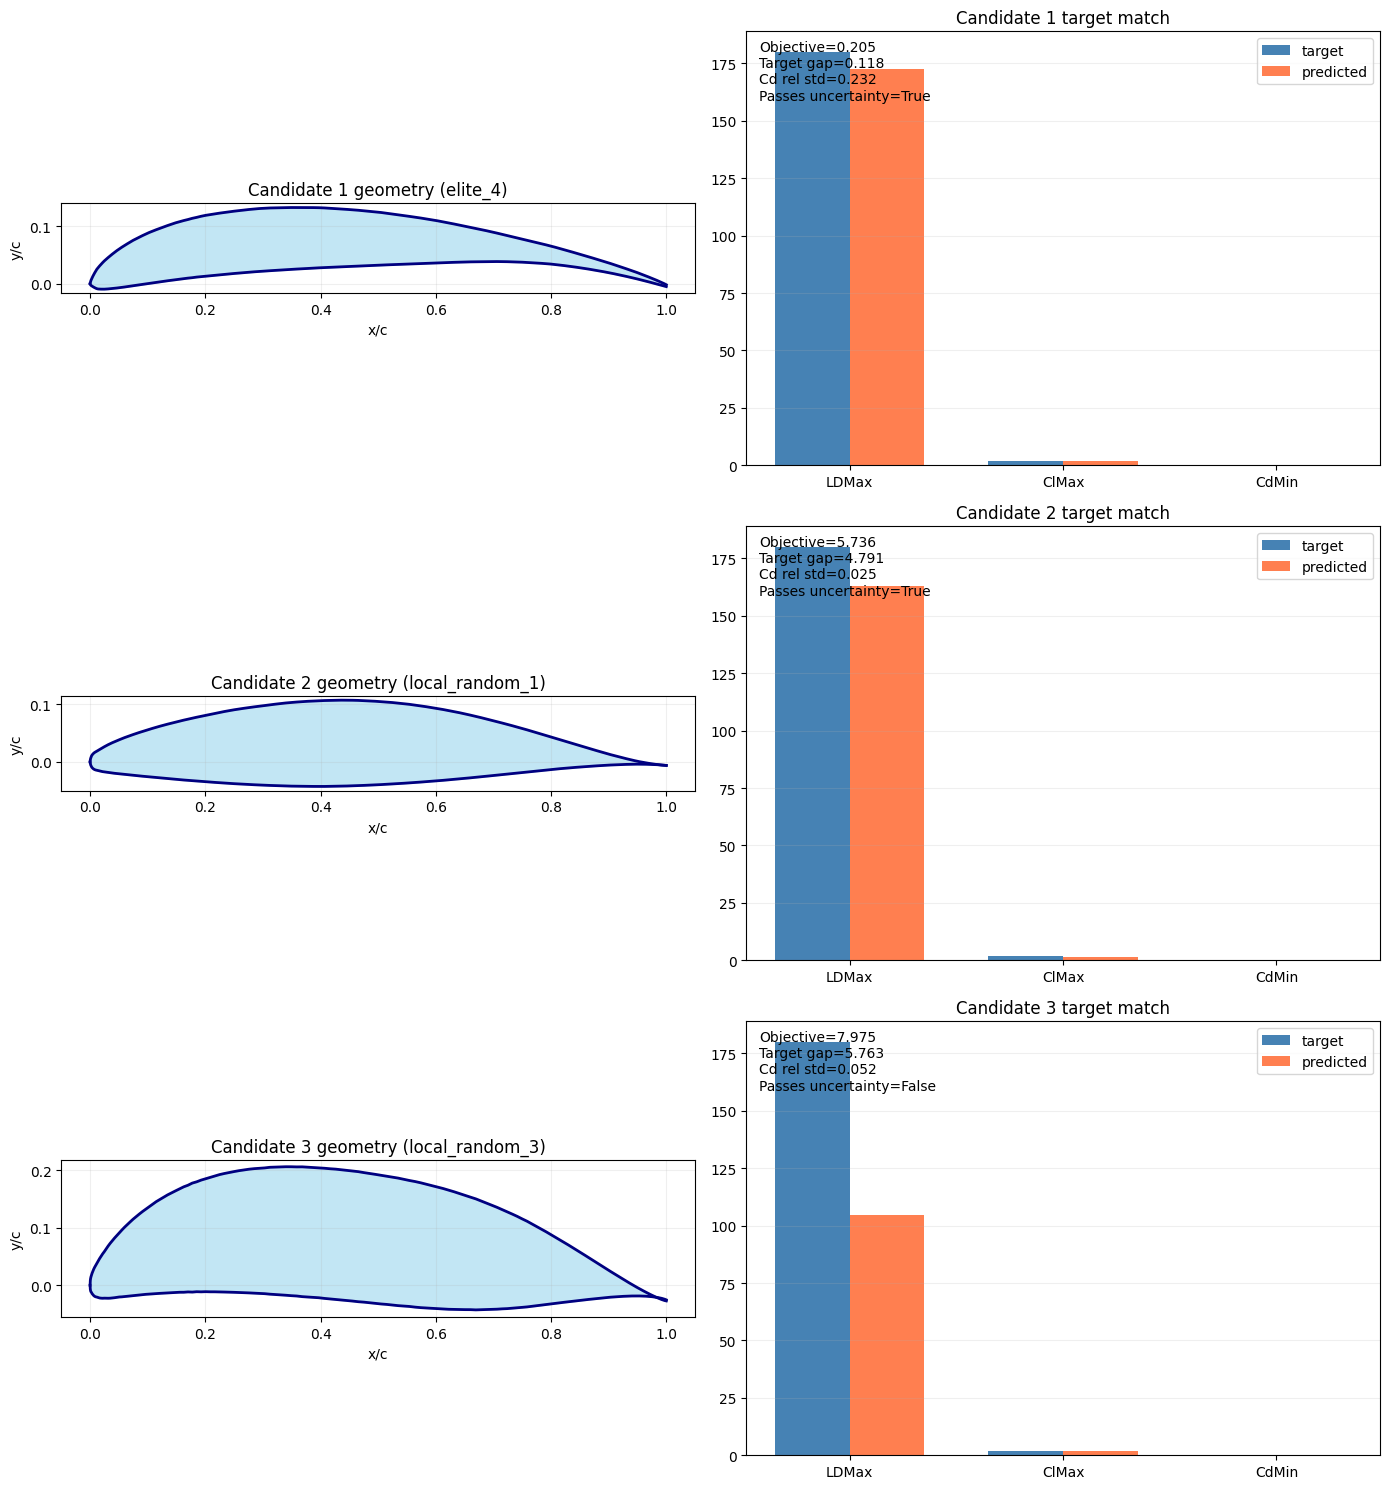

Saved reverse-design v3 artifacts
Summary    : /kaggle/working/aeroml_reverse_design_v3/reverse_design_v3_summary.json
Feasibility: /kaggle/working/aeroml_reverse_design_v3/reverse_design_v3_feasibility.json
Candidates : /kaggle/working/aeroml_reverse_design_v3/reverse_design_v3_candidates.csv
All runs   : /kaggle/working/aeroml_reverse_design_v3/reverse_design_v3_all_results.csv
Coords     : /kaggle/working/aeroml_reverse_design_v3


In [6]:
if candidate_df.empty:
    raise RuntimeError("No reverse-design candidates were produced.")

n_show = len(top_results)
fig, axes = plt.subplots(n_show, 2, figsize=(14, 5 * n_show))
if n_show == 1:
    axes = np.array([axes])

for row_axes, item, row in zip(axes, top_results, candidate_rows):
    left_ax, right_ax = row_axes
    left_ax.plot(x_grid, item["inputs"]["y_upper"], color="navy", linewidth=2)
    left_ax.plot(x_grid, item["inputs"]["y_lower"], color="navy", linewidth=2)
    left_ax.fill_between(x_grid, item["inputs"]["y_lower"], item["inputs"]["y_upper"], color="skyblue", alpha=0.5)
    left_ax.set_aspect("equal")
    left_ax.grid(alpha=0.2)
    left_ax.set_title(f"Candidate {row['rank']} geometry ({row['source']})")
    left_ax.set_xlabel("x/c")
    left_ax.set_ylabel("y/c")

    metrics = ["LDMax", "ClMax", "CdMin"]
    target_vals = [TARGET["LDMax"], TARGET["ClMax"], TARGET["CdMin"]]
    pred_vals = [row["LDMax_pred"], row["ClMax_pred"], row["CdMin_pred"]]
    x_pos = np.arange(len(metrics))
    width = 0.35
    right_ax.bar(x_pos - width / 2, target_vals, width, label="target", color="steelblue")
    right_ax.bar(x_pos + width / 2, pred_vals, width, label="predicted", color="coral")
    right_ax.set_xticks(x_pos)
    right_ax.set_xticklabels(metrics)
    right_ax.set_title(f"Candidate {row['rank']} target match")
    right_ax.legend()
    right_ax.grid(alpha=0.2, axis="y")
    right_ax.text(
        0.02, 0.98,
        f"Objective={row['objective']:.3f}\nTarget gap={row['target_gap']:.3f}\nCd rel std={row['CdMin_rel_std']:.3f}\nPasses uncertainty={row['passes_uncertainty']}",
        transform=right_ax.transAxes, va="top"
    )

plt.tight_layout()
plt.show()

print("Saved reverse-design v3 artifacts")
print("=" * 72)
print("Summary    :", SUMMARY_PATH)
print("Feasibility:", FEASIBILITY_PATH)
print("Candidates :", CANDIDATE_TABLE_PATH)
print("All runs   :", ALL_RESULTS_PATH)
print("Coords     :", OUT_DIR)
